In [10]:
# Importamos librerías para optimización con pipelines

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR



In [3]:
# Cargamos el dataset preparado para el Modelo A

df = pd.read_csv("data_limpio/features_modelo_A.csv")


In [4]:
# Separamos el dataset por bloques temporales

train = df[df["bloque"] == "train"].copy()

valid = df[df["bloque"] == "validacion"].copy()

test = df[df["bloque"] == "test"].copy()

In [5]:
# Definimos variables predictoras y target

columnas_no_modelo = ["Time", "bloque", "LT411"]

X_train = train.drop(columns=columnas_no_modelo)
y_train = train["LT411"]

X_valid = valid.drop(columns=columnas_no_modelo)
y_valid = valid["LT411"]

X_test = test.drop(columns=columnas_no_modelo)
y_test = test["LT411"]

In [6]:
# Revisamos tamaños de train, validación y test

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (8634, 97)
y_train: (8634,)
X_valid: (8634, 97)
y_valid: (8634,)
X_test: (5784, 97)
y_test: (5784,)


In [7]:
# Creamos una función simple para calcular métricas de regresión

def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    
    return mae, rmse, r2

In [11]:
# Definimos validación cruzada temporal para GridSearchCV

tscv = TimeSeriesSplit(n_splits=3)

In [12]:
# Definimos los modelos candidatos

modelos = {
    "RandomForest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    ),
    
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR())
    ])
}

In [13]:
# Definimos los hiperparámetros de cada modelo

params = {
    "RandomForest": {
        "n_estimators": [200, 400],
        "max_depth": [8, 10, 15],
        "min_samples_leaf": [2, 5, 10],
        "max_features": ["sqrt", 0.7, 1.0]
    },
    
    "GradientBoosting": {
        "n_estimators": [100, 200, 400],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [2, 3, 4],
        "subsample": [0.8, 1.0]
    },
    
    "SVR": {
        "svr__kernel": ["rbf"],
        "svr__C": [1, 10, 50],
        "svr__epsilon": [0.05, 0.1, 0.5],
        "svr__gamma": ["scale", "auto"]
    }
}

In [14]:
# Optimizamos cada modelo con GridSearchCV

resultados = []

mejores_modelos = {}

for nombre, modelo in modelos.items():
    
    print("Modelo:", nombre)
    
    gs = GridSearchCV(
        estimator=modelo,
        param_grid=params[nombre],
        cv=tscv,
        scoring="neg_mean_absolute_error",
        verbose=1,
        n_jobs=-1
    )
    
    gs.fit(X_train, y_train)
    
    mejor_modelo = gs.best_estimator_
    
    mejores_modelos[nombre] = mejor_modelo
    
    pred_train = mejor_modelo.predict(X_train)
    pred_valid = mejor_modelo.predict(X_valid)
    
    mae_train, rmse_train, r2_train = calcular_metricas(y_train, pred_train)
    mae_valid, rmse_valid, r2_valid = calcular_metricas(y_valid, pred_valid)
    
    resultados.append({
        "modelo": nombre,
        "MAE_CV": -gs.best_score_,
        "MAE_train": mae_train,
        "RMSE_train": rmse_train,
        "R2_train": r2_train,
        "MAE_valid": mae_valid,
        "RMSE_valid": rmse_valid,
        "R2_valid": r2_valid,
        "best_params": gs.best_params_
    })
    
    print("  Mejor MAE CV:", -gs.best_score_)
    print("  MAE validación:", mae_valid)
    print("  R2 validación:", r2_valid)
    print("  Mejores parámetros:", gs.best_params_)
    print("-" * 60)

Modelo: RandomForest
Fitting 3 folds for each of 54 candidates, totalling 162 fits
  Mejor MAE CV: 2.6619361581875496
  MAE validación: 4.378032097470721
  R2 validación: 0.03033160092820264
  Mejores parámetros: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 400}
------------------------------------------------------------
Modelo: GradientBoosting
Fitting 3 folds for each of 54 candidates, totalling 162 fits
  Mejor MAE CV: 2.69952340913551
  MAE validación: 4.319667908677303
  R2 validación: 0.04712520079181526
  Mejores parámetros: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
------------------------------------------------------------
Modelo: SVR
Fitting 3 folds for each of 18 candidates, totalling 54 fits
  Mejor MAE CV: 2.576895944323012
  MAE validación: 4.011738124483978
  R2 validación: 0.09701925465276584
  Mejores parámetros: {'svr__C': 1, 'svr__epsilon': 0.5, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}
---

In [15]:
# Creamos tabla comparativa de modelos optimizados

df_resultados_opt = pd.DataFrame(resultados)

df_resultados_opt["gap_MAE"] = df_resultados_opt["MAE_valid"] - df_resultados_opt["MAE_train"]

df_resultados_opt = df_resultados_opt.sort_values("MAE_valid").reset_index(drop=True)

df_resultados_opt

,modelo,MAE_CV,MAE_train,RMSE_train,R2_train,MAE_valid,RMSE_valid,R2_valid,best_params,gap_MAE
0,SVR,2.576896,1.426711,1.901165,0.723932,4.011738,5.863449,0.097019,"{'svr__C': 1, 'svr__epsilon': 0.5, 'svr__gamma...",2.585027
1,GradientBoosting,2.699523,2.052943,2.563119,0.498219,4.319668,6.023263,0.047125,"{'learning_rate': 0.03, 'max_depth': 3, 'n_est...",2.266725
2,RandomForest,2.661936,1.627173,2.045637,0.680380,4.378032,6.076108,0.030332,"{'max_depth': 8, 'max_features': 'sqrt', 'min_...",2.750859


In [16]:
# Seleccionamos el mejor modelo según MAE de validación

mejor_modelo_nombre = df_resultados_opt.loc[0, "modelo"]

mejor_modelo = mejores_modelos[mejor_modelo_nombre]

print("Mejor modelo optimizado:", mejor_modelo_nombre)

Mejor modelo optimizado: SVR


In [17]:
# Revisamos los mejores parámetros del modelo ganador

df_resultados_opt.loc[0, "best_params"]

{'svr__C': 1, 'svr__epsilon': 0.5, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}

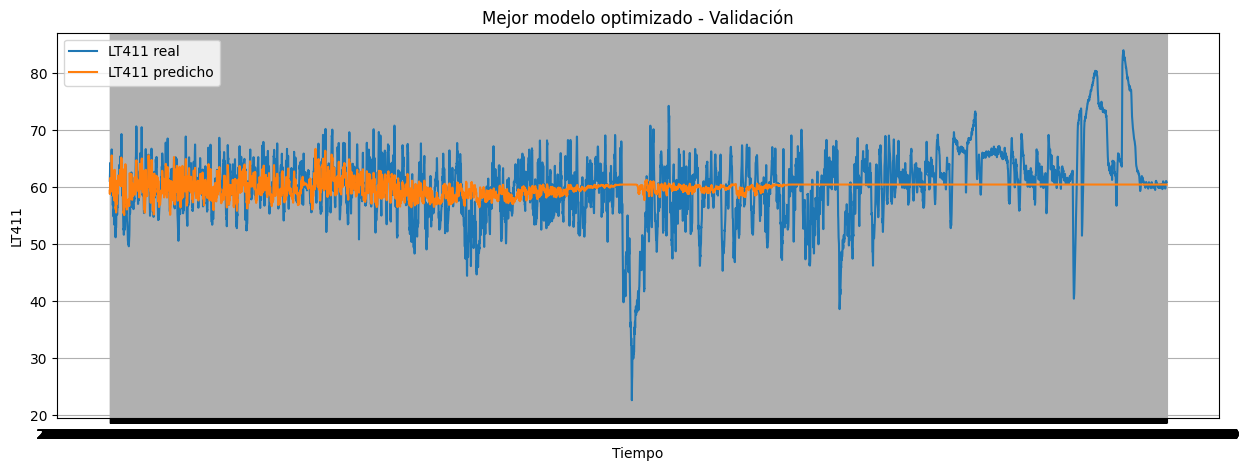

In [18]:
# Graficamos el mejor modelo en validación

pred_valid_mejor = mejor_modelo.predict(X_valid)

plt.figure(figsize=(15, 5))

plt.plot(valid["Time"], y_valid, label="LT411 real")
plt.plot(valid["Time"], pred_valid_mejor, label="LT411 predicho")

plt.title("Mejor modelo optimizado - Validación")
plt.xlabel("Tiempo")
plt.ylabel("LT411")
plt.grid(True)
plt.legend()
plt.show()